# CNN composer classifier

Same splits, same labels, same evaluation as `05_lstm_model` — the only thing that changes is the representation. Here each piece is a piano roll image (88 pitches x time) and we run a small 2D convnet over it.

Shapes are defined in `docs/interface-contract.md`.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

CNN_DIR = Path("../data/processed/cnn")
SPLIT_DIR = Path("../data/splits")
MODEL_DIR = Path("../models")
RESULTS_DIR = Path("../results")
MODEL_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

COMPOSERS = ["bach", "beethoven", "chopin", "mozart"]
LABEL = {c: i for i, c in enumerate(COMPOSERS)}

PITCHES = 88
MAX_STEPS = 512   # rolls run to 6k steps; we read the opening 512
EPOCHS = 100
BATCH = 32
LR = 1e-3
PATIENCE = 12

print(tf.__version__)

2.21.0


## Load the piano rolls

Kept as `uint8` in memory (~100 MB for the whole train set instead of ~400 MB as float32); the `/127` scaling happens inside the model as a `Rescaling` layer.

In [2]:
def load_roll(composer, filename):
    """npy -> (88, MAX_STEPS) uint8, cropped or right-zero-padded."""
    a = np.load(CNN_DIR / composer / (Path(filename).stem + ".npy"))
    x = np.zeros((PITCHES, MAX_STEPS), dtype=np.uint8)
    t = min(a.shape[1], MAX_STEPS)
    x[:, :t] = a[:, :t]
    return x


def load_split(name):
    df = pd.read_csv(SPLIT_DIR / f"{name}.csv")
    X = np.stack([load_roll(r.composer, r.filename) for r in df.itertuples()])[..., None]
    y = df["composer"].map(LABEL).to_numpy()
    return X, y, df


X_train, y_train, train_df = load_split("train")
X_val, y_val, _ = load_split("val")
X_test, y_test, _ = load_split("test")

print("train", X_train.shape, X_train.dtype, f"{X_train.nbytes / 1e6:.0f} MB")
print("val  ", X_val.shape, "test", X_test.shape)
print(f"roll density (fraction of non-zero cells): train {(X_train > 0).mean():.3f}, "
      f"val {(X_val > 0).mean():.3f}")

train (2188, 88, 512, 1) uint8 99 MB
val   (245, 88, 512, 1) test (246, 88, 512, 1)
roll density (fraction of non-zero cells): train 0.032, val 0.029


In [3]:
# Same weighting rule as the LSTM notebook: from the unaugmented counts.
orig = train_df.loc[~train_df["is_augmented"], "composer"].map(LABEL).to_numpy()
weights = compute_class_weight("balanced", classes=np.arange(4), y=orig)
class_weight = dict(enumerate(weights))
dict(zip(COMPOSERS, weights.round(3)))

{'bach': np.float64(0.399),
 'beethoven': np.float64(1.869),
 'chopin': np.float64(3.011),
 'mozart': np.float64(1.598)}

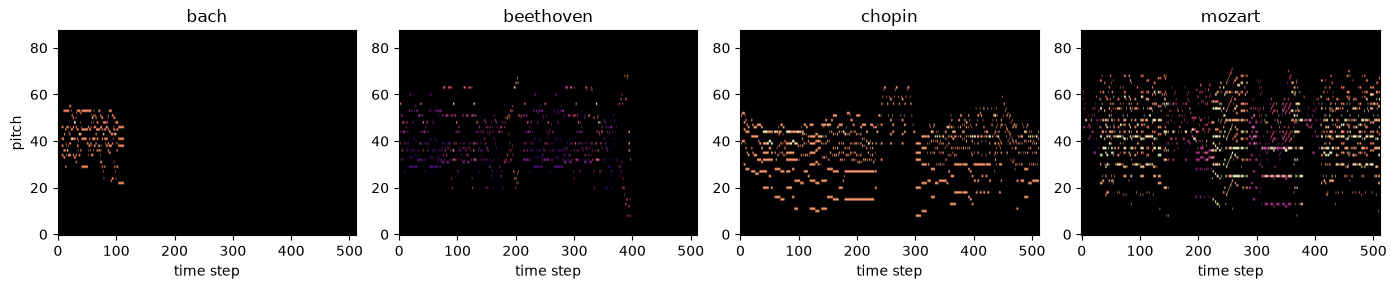

In [4]:
# What the model actually sees.
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, c in zip(axes, COMPOSERS):
    i = int(np.where(y_train == LABEL[c])[0][0])
    ax.imshow(X_train[i, :, :, 0], aspect="auto", origin="lower", cmap="magma")
    ax.set(title=c, xlabel="time step", ylabel="pitch" if c == COMPOSERS[0] else "")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "piano_roll_examples.png", dpi=120)
plt.show()

## Model

Three conv blocks, then global average pooling instead of a flatten — pooling keeps the head small and makes the model care about *whether* a texture appears rather than exactly where in the 512 steps it appears.

**No BatchNorm, deliberately.** The first version of this notebook put a `BatchNormalization` layer in each block and it broke the model outright. Piano rolls are ~97% zeros, so activation variance is tiny, BN's running mean/variance end up meaningless, and at inference the model collapsed to predicting a single class for every input: validation accuracy pinned at exactly 0.086 (chopin's share of the val set) for every epoch while training accuracy climbed to 0.72 and validation loss ran away to 67. The same weights scored normally when forced to use *batch* statistics instead of the running ones, which is what pinned the blame on BN rather than on the data. Dropout does the regularising here instead.

In [5]:
def conv_block(x, filters, drop):
    x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling2D(2)(x)
    return tf.keras.layers.Dropout(drop)(x)


inputs = tf.keras.layers.Input((PITCHES, MAX_STEPS, 1))
x = tf.keras.layers.Rescaling(1 / 127.0)(inputs)
x = conv_block(x, 32, 0.2)
x = conv_block(x, 64, 0.2)
x = conv_block(x, 128, 0.3)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(64, activation="relu")(x)
outputs = tf.keras.layers.Dense(4, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs, name="cnn_composer")
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

Model: "cnn_composer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 88, 512, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 88, 512, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 88, 512, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 256, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 44, 256, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 256, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 128, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 22, 128, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 11, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 11, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,188 (395.27 KB)

 Trainable params: 101,188 (395.27 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=PATIENCE, restore_best_weights=True, verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH,
    class_weight=class_weight,
    callbacks=[early],
    verbose=2,
)

model.save(MODEL_DIR / "cnn.keras")

Epoch 1/100


69/69 - 13s - 190ms/step - accuracy: 0.2294 - loss: 2.0078 - val_accuracy: 0.0857 - val_loss: 1.8006


Epoch 2/100


69/69 - 13s - 185ms/step - accuracy: 0.2527 - loss: 1.9545 - val_accuracy: 0.1224 - val_loss: 1.7479


Epoch 3/100


...

69/69 - 11s - 165ms/step - accuracy: 0.8131 - loss: 0.5666 - val_accuracy: 0.8694 - val_loss: 0.3662


Epoch 91/100


69/69 - 12s - 167ms/step - accuracy: 0.8195 - loss: 0.5476 - val_accuracy: 0.8694 - val_loss: 0.3758


Epoch 91: early stopping


Restoring model weights from the end of the best epoch: 79.


In [7]:
# Sanity check that the BN failure has not come back in another form: the model
# must not be predicting a single class for the whole validation set.
val_pred = model.predict(X_val, verbose=0).argmax(axis=1)
print("val predictions per class:", dict(zip(COMPOSERS, np.bincount(val_pred, minlength=4))))
assert len(np.unique(val_pred)) > 1, "model collapsed to one class on validation"
print("val accuracy:", (val_pred == y_val).mean().round(3))

val predictions per class: {'bach': np.int64(145), 'beethoven': np.int64(26), 'chopin': np.int64(26), 'mozart': np.int64(48)}
val accuracy: 0.873


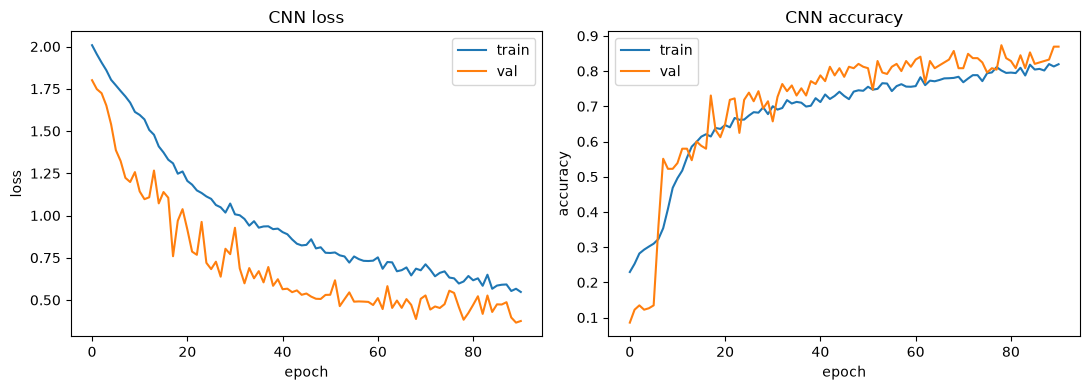

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history.history["loss"], label="train")
ax[0].plot(history.history["val_loss"], label="val")
ax[0].set(title="CNN loss", xlabel="epoch", ylabel="loss")
ax[0].legend()
ax[1].plot(history.history["accuracy"], label="train")
ax[1].plot(history.history["val_accuracy"], label="val")
ax[1].set(title="CNN accuracy", xlabel="epoch", ylabel="accuracy")
ax[1].legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "history_cnn.png", dpi=120)
plt.show()

## Test set evaluation

In [9]:
def evaluate(model, X, y, name):
    """Score on the test set, write results/<name>_metrics.json, return the dict."""
    y_pred = model.predict(X, verbose=0).argmax(axis=1)
    p_mac, r_mac, _, _ = precision_recall_fscore_support(
        y, y_pred, average="macro", zero_division=0)
    p_w, r_w, _, _ = precision_recall_fscore_support(
        y, y_pred, average="weighted", zero_division=0)
    p, r, f1, sup = precision_recall_fscore_support(
        y, y_pred, labels=range(4), zero_division=0)

    metrics = {
        "model": name,
        "accuracy": float((y_pred == y).mean()),
        "precision_macro": float(p_mac),
        "recall_macro": float(r_mac),
        "precision_weighted": float(p_w),
        "recall_weighted": float(r_w),
        "per_class": {
            c: {"precision": float(p[i]), "recall": float(r[i]),
                "f1": float(f1[i]), "support": int(sup[i])}
            for i, c in enumerate(COMPOSERS)
        },
        "confusion_matrix": confusion_matrix(y, y_pred, labels=range(4)).tolist(),
        "history": {k: [float(v) for v in vs] for k, vs in history.history.items()},
        "params": {"max_steps": MAX_STEPS, "epochs_run": len(history.history["loss"]),
                   "max_epochs": EPOCHS, "batch": BATCH, "lr": LR,
                   "patience": PATIENCE, "seed": SEED},
    }
    (RESULTS_DIR / f"{name}_metrics.json").write_text(json.dumps(metrics, indent=2))
    print(classification_report(y, y_pred, target_names=COMPOSERS, zero_division=0))
    print(f"majority-class baseline: {np.bincount(y).max() / len(y):.3f}")
    return metrics


metrics = evaluate(model, X_test, y_test, "cnn")
metrics["accuracy"], metrics["precision_macro"], metrics["recall_macro"]

              precision    recall  f1-score   support

        bach       0.92      0.92      0.92       154
   beethoven       0.64      0.48      0.55        33
      chopin       0.53      0.80      0.64        20
      mozart       0.53      0.51      0.52        39

    accuracy                           0.78       246
   macro avg       0.66      0.68      0.66       246
weighted avg       0.79      0.78      0.78       246

majority-class baseline: 0.626


(0.7845528455284553, 0.6553044375644994, 0.6783133533133534)

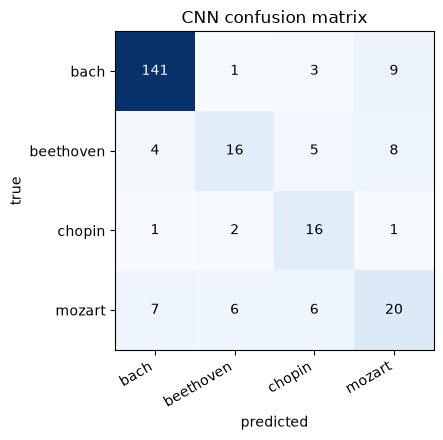

In [10]:
def plot_confusion(cm, title, path):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.imshow(cm, cmap="Blues")
    ax.set(xticks=range(4), yticks=range(4), xticklabels=COMPOSERS,
           yticklabels=COMPOSERS, xlabel="predicted", ylabel="true", title=title)
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
    thresh = cm.max() / 2
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    fig.savefig(path, dpi=120)
    plt.show()


plot_confusion(metrics["confusion_matrix"], "CNN confusion matrix",
               RESULTS_DIR / "confusion_cnn.png")

## Notes

- The roll is cropped to the first 512 time steps, same reasoning (and same limitation) as the LSTM's 500-note window.
- Velocity is kept as the pixel value rather than binarising note-on/note-off, so dynamics are part of what the convnet can key on.
- Global average pooling makes the model translation-invariant along time, which matters because the crop start is arbitrary.
- BatchNorm is deliberately absent — see the model section for the failure it caused on sparse piano rolls. The assertion after training is there so a silent return of that collapse fails the notebook instead of producing a plausible-looking bad number.